<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 17: Advanced Regression for Earth Sciences
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  
**Reference:** Chapter 16

**Topic:** Multiple Linear Regression, Polynomial Regression, and Non-linear GNSS Modeling  

This notebook covers:
1. **Regression Assumptions** (Residual analysis & Homoscedasticity)
2. **Multiple Linear Regression** (VIF & Multicollinearity)
3. **Polynomial Regression** (The Bias-Variance Tradeoff)
4. **Non-linear GNSS Modeling** (Offsets, Postseismic Decay, and Grid Search for $\tau$)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import requests
import io

# Plotting settings
plt.rcParams['figure.figsize'] = [10, 6]
plt.style.use('ggplot')

## 1. Assumptions of Linear Regression
According to the lecture, we must assume:
- **Normal Distribution of Residuals**: Errors should be Gaussian.
- **Homoscedasticity**: The variance of residuals remains constant across X.
- **Linearity**: The relationship is fundamentally a straight line.

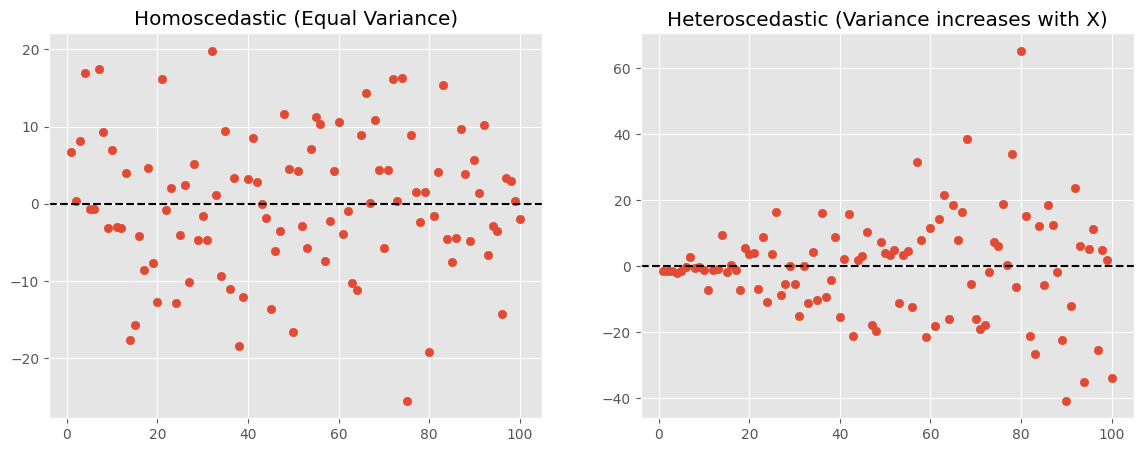

In [ ]:
# Demonstrating Homoscedasticity vs Heteroscedasticity
np.random.seed(42)
x = np.linspace(1, 100, 100)
y_homo = 2 * x + 5 + np.random.normal(0, 10, 100)
y_hetero = 2 * x + 5 + np.random.normal(0, x * 0.3, 100)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Homoscedastic Residuals
model1 = sm.OLS(y_homo, sm.add_constant(x)).fit()
ax[0].scatter(x, model1.resid)
ax[0].axhline(0, color='black', linestyle='--')
ax[0].set_title("Homoscedastic (Equal Variance)")

# Heteroscedastic Residuals
model2 = sm.OLS(y_hetero, sm.add_constant(x)).fit()
ax[1].scatter(x, model2.resid)
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title("Heteroscedastic (Variance increases with X)")
plt.show()

## 2. Multiple Linear Regression (MLR) & VIF
MLR models $Y$ based on multiple $X$ predictors. We use the **Variance Inflation Factor (VIF)** to check for multicollinearity (when predictors are too correlated).
- **VIF > 5-10**: Suggests high multicollinearity.

In [ ]:
# Create synthetic soil moisture data
data = pd.DataFrame({
    'Precip': [10, 2, 15, 20, 5, 0, 12, 8],
    'Temp': [15, 25, 12, 10, 20, 30, 14, 18],
    'Moisture': [30, 10, 35, 40, 18, 5, 32, 22]
})

X = sm.add_constant(data[['Precip', 'Temp']])
mlr_model = sm.OLS(data['Moisture'], X).fit()

# Calculate VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(mlr_model.summary())
print("\nVIF Values:\n", vif)

                            OLS Regression Results                            
Dep. Variable:               Moisture   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     249.1
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           9.84e-06
Time:                        20:12:26   Log-Likelihood:                -12.504
No. Observations:                   8   AIC:                             31.01
Df Residuals:                       5   BIC:                             31.25
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.6496      7.473      5.306      0.0

## 3. Polynomial Regression & Overfitting
We add $X^2, X^3 \dots$ terms for curved relationships. However, a high-degree polynomial (e.g., 15th degree) can "overfit" by modeling noise instead of the signal.

/tmp/ipykernel_7634/1247534118.py:6: RankWarning: Polyfit may be poorly conditioned
  p15 = np.poly1d(np.polyfit(x_poly, y_poly, 15)) # Overfit


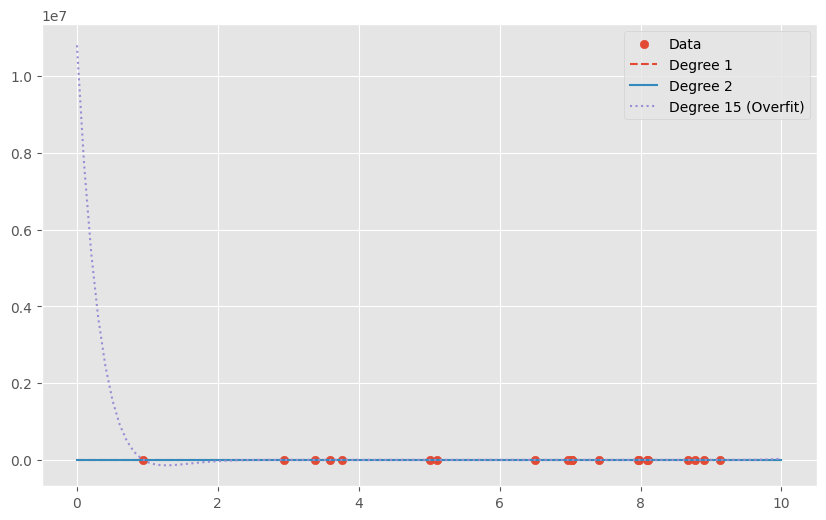

In [ ]:
x_poly = np.sort(np.random.uniform(0, 10, 20))
y_poly = 0.5 * x_poly**2 + np.random.normal(0, 5, 20)

p1 = np.poly1d(np.polyfit(x_poly, y_poly, 1))  # Underfit
p2 = np.poly1d(np.polyfit(x_poly, y_poly, 2))  # Good Fit
p15 = np.poly1d(np.polyfit(x_poly, y_poly, 15)) # Overfit

xp = np.linspace(0, 10, 100)
plt.scatter(x_poly, y_poly, label="Data")
plt.plot(xp, p1(xp), '--', label="Degree 1")
plt.plot(xp, p2(xp), '-', label="Degree 2")
plt.plot(xp, p15(xp), ':', label="Degree 15 (Overfit)")
plt.legend()
plt.show()

## 4. Non-Linear GNSS Modeling (Station J549)
We will model the East displacement for station J549. The model includes:
1. **Linear Trend**: $a + bt$
2. **Seasonal Cycles**: $\sin(2\pi t) + \cos(2\pi t)$
3. **Offsets**: Heaviside steps $H(t)$ for the 2003 Tokachi-oki and 2011 Tohoku earthquakes.
4. **Postseismic Decay**: $k \cdot \ln(1 + \Delta t/\tau)$.

**Grid Search**: Since $\tau$ is non-linear (embedded in the log), we iterate through possible $\tau$ values to minimize the Residual Sum of Squares (RSS).

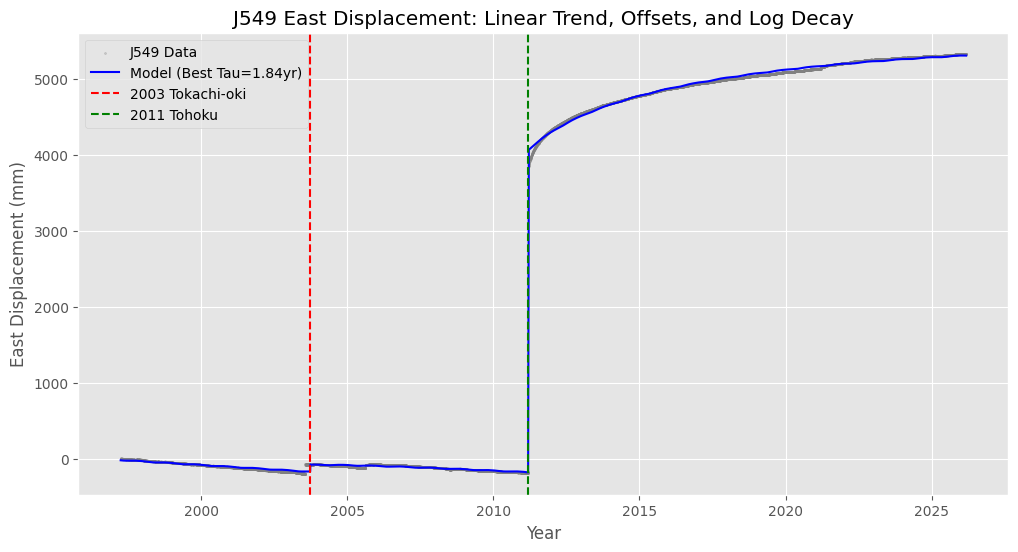

Optimal Tau: 1.841 years
Calculated Velocity: -23.730 mm/yr


In [10]:
# 1. Load Data
url = "https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/OK/J549.OK.tenv3"
response = requests.get(url)

# Fix 1: Use 'skiprows=1' to ignore the header text row
# Fix 2: Use r'\s+' (raw string) to avoid the SyntaxWarning
df = pd.read_csv(io.StringIO(response.text), sep=r'\s+', header=None, skiprows=1, usecols=[2, 8])
df.columns = ['time', 'east_m']

# Fix 3: Explicitly convert columns to numeric to ensure no strings are left
df['time'] = pd.to_numeric(df['time'], errors='coerce')
df['east_m'] = pd.to_numeric(df['east_m'], errors='coerce')
df = df.dropna() # Remove any rows that failed to convert

df['east_mm'] = (df['east_m'] - df['east_m'].iloc[0]) * 1000 # Relative mm

t = df['time'].values
y = df['east_mm'].values

# Dates for Earthquakes
T_tokachi = 2003.734  # 2003 Tokachi-oki
T_tohoku = 2011.192   # 2011 Tohoku

def build_design_matrix(t_vec, tau_val):
    """Creates the G matrix for a specific tau value."""
    # Constant + Velocity + Seasonal
    G = np.column_stack([
        np.ones_like(t_vec),
        t_vec - t_vec[0],
        np.sin(2*np.pi*t_vec),
        np.cos(2*np.pi*t_vec),
        np.sin(4*np.pi*t_vec),
        np.cos(4*np.pi*t_vec)
    ])

    # Tokachi-oki terms (Offset + Log Decay)
    dt1 = t_vec - T_tokachi
    H1 = (dt1 >= 0).astype(float)
    # Log term: adding a small epsilon to avoid log(0)
    G = np.column_stack([G, H1, H1 * np.log(1 + np.maximum(0, dt1)/tau_val)])

    # Tohoku terms (Offset + Log Decay)
    dt2 = t_vec - T_tohoku
    H2 = (dt2 >= 0).astype(float)
    G = np.column_stack([G, H2, H2 * np.log(1 + np.maximum(0, dt2)/tau_val)])

    return G

# 2. Grid Search for Tau
tau_candidates = np.linspace(0.01, 3.0, 50) # Search range for tau (years)
rss_results = []

for tau in tau_candidates:
    G = build_design_matrix(t, tau)
    # Solve via Least Squares
    m, residuals, rank, s = np.linalg.lstsq(G, y, rcond=None)
    # Handle cases where residuals might be empty
    rss_val = residuals[0] if len(residuals) > 0 else np.sum((y - G @ m)**2)
    rss_results.append(rss_val)

# Identify best tau
best_tau = tau_candidates[np.argmin(rss_results)]
G_best = build_design_matrix(t, best_tau)
m_best, _, _, _ = np.linalg.lstsq(G_best, y, rcond=None)
y_pred = G_best @ m_best

# 3. Visualization
plt.figure(figsize=(12, 6))
plt.scatter(t, y, s=2, color='gray', alpha=0.3, label="J549 Data")
plt.plot(t, y_pred, color='blue', label=f"Model (Best Tau={best_tau:.2f}yr)")
plt.axvline(T_tokachi, color='red', linestyle='--', label="2003 Tokachi-oki")
plt.axvline(T_tohoku, color='green', linestyle='--', label="2011 Tohoku")
plt.title("J549 East Displacement: Linear Trend, Offsets, and Log Decay")
plt.xlabel("Year")
plt.ylabel("East Displacement (mm)")
plt.legend()
plt.show()

print(f"Optimal Tau: {best_tau:.3f} years")
print(f"Calculated Velocity: {m_best[1]:.3f} mm/yr")